In [1]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [3]:
features = df.columns.drop('Outcome')
print("features names are: ", features.tolist())

features names are:  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [4]:
target = df.columns[-1]
print("target is: ", target)

target is:  Outcome


In [5]:
print("size of dataset is: ", df.shape)

size of dataset is:  (768, 9)


In [6]:
forQuality = df.duplicated().sum()
print("quality of dataset is: ", "dataset is clean" if forQuality == 0 else "dataset has duplicates")

quality of dataset is:  dataset is clean


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
import numpy as np
# Replace 0 values with NaN in specific columns
df_copy = df.copy()
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)
#why do we do this? because 0 values in these columns are not valid and can skew the analysis. For example, a blood pressure of 0 is not physiologically possible, so it should be treated as missing data.

In [11]:
print("----------------new one---------------------")
print(df_copy.isnull().sum())
print("----------------old one---------------------")
print(df.isnull().sum())

----------------new one---------------------
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
----------------old one---------------------
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


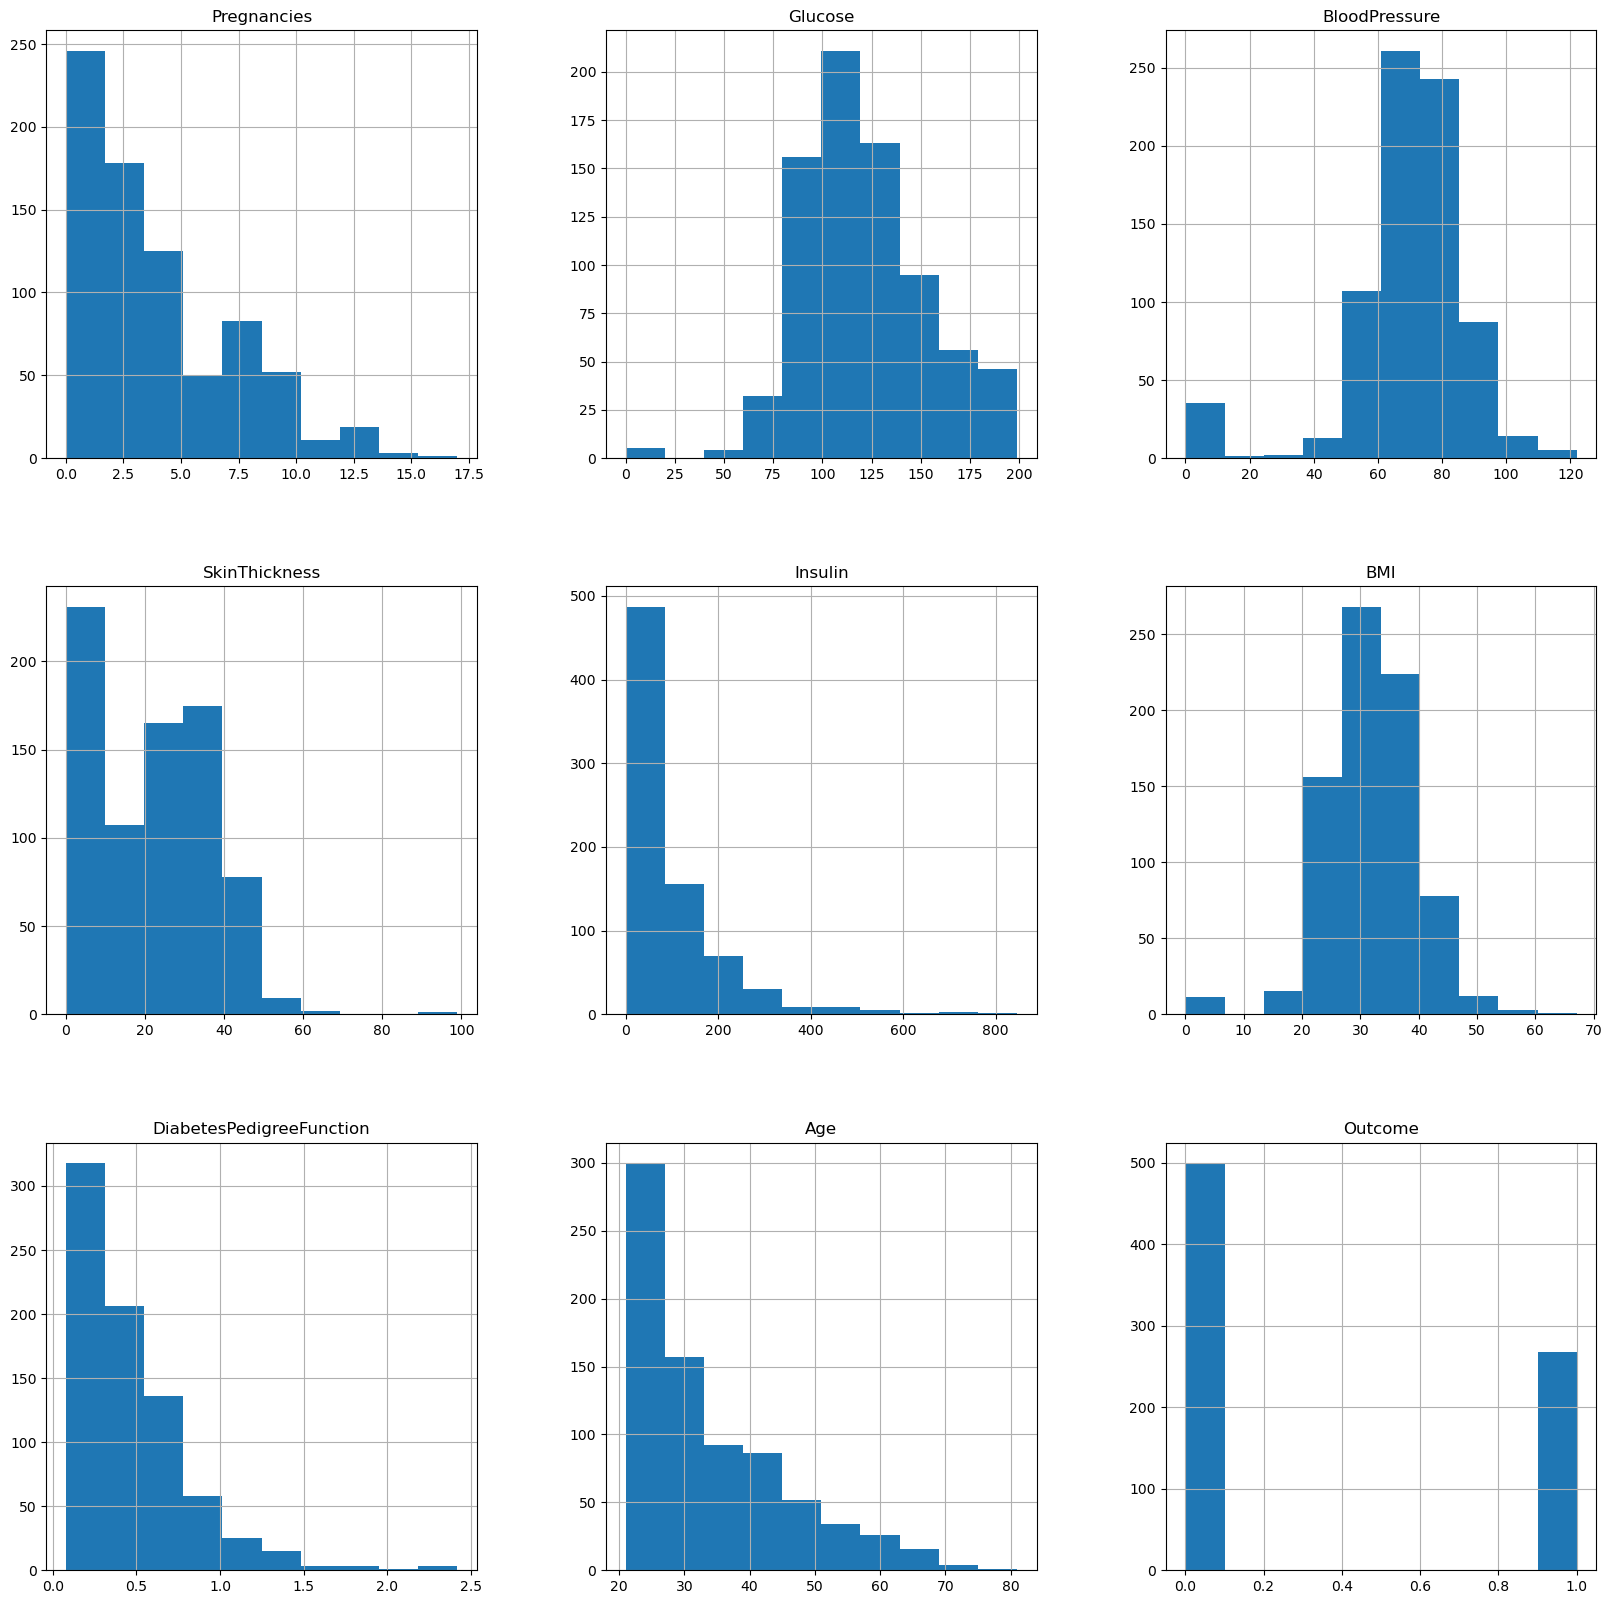

In [12]:
p = df.hist(figsize = (20,20))

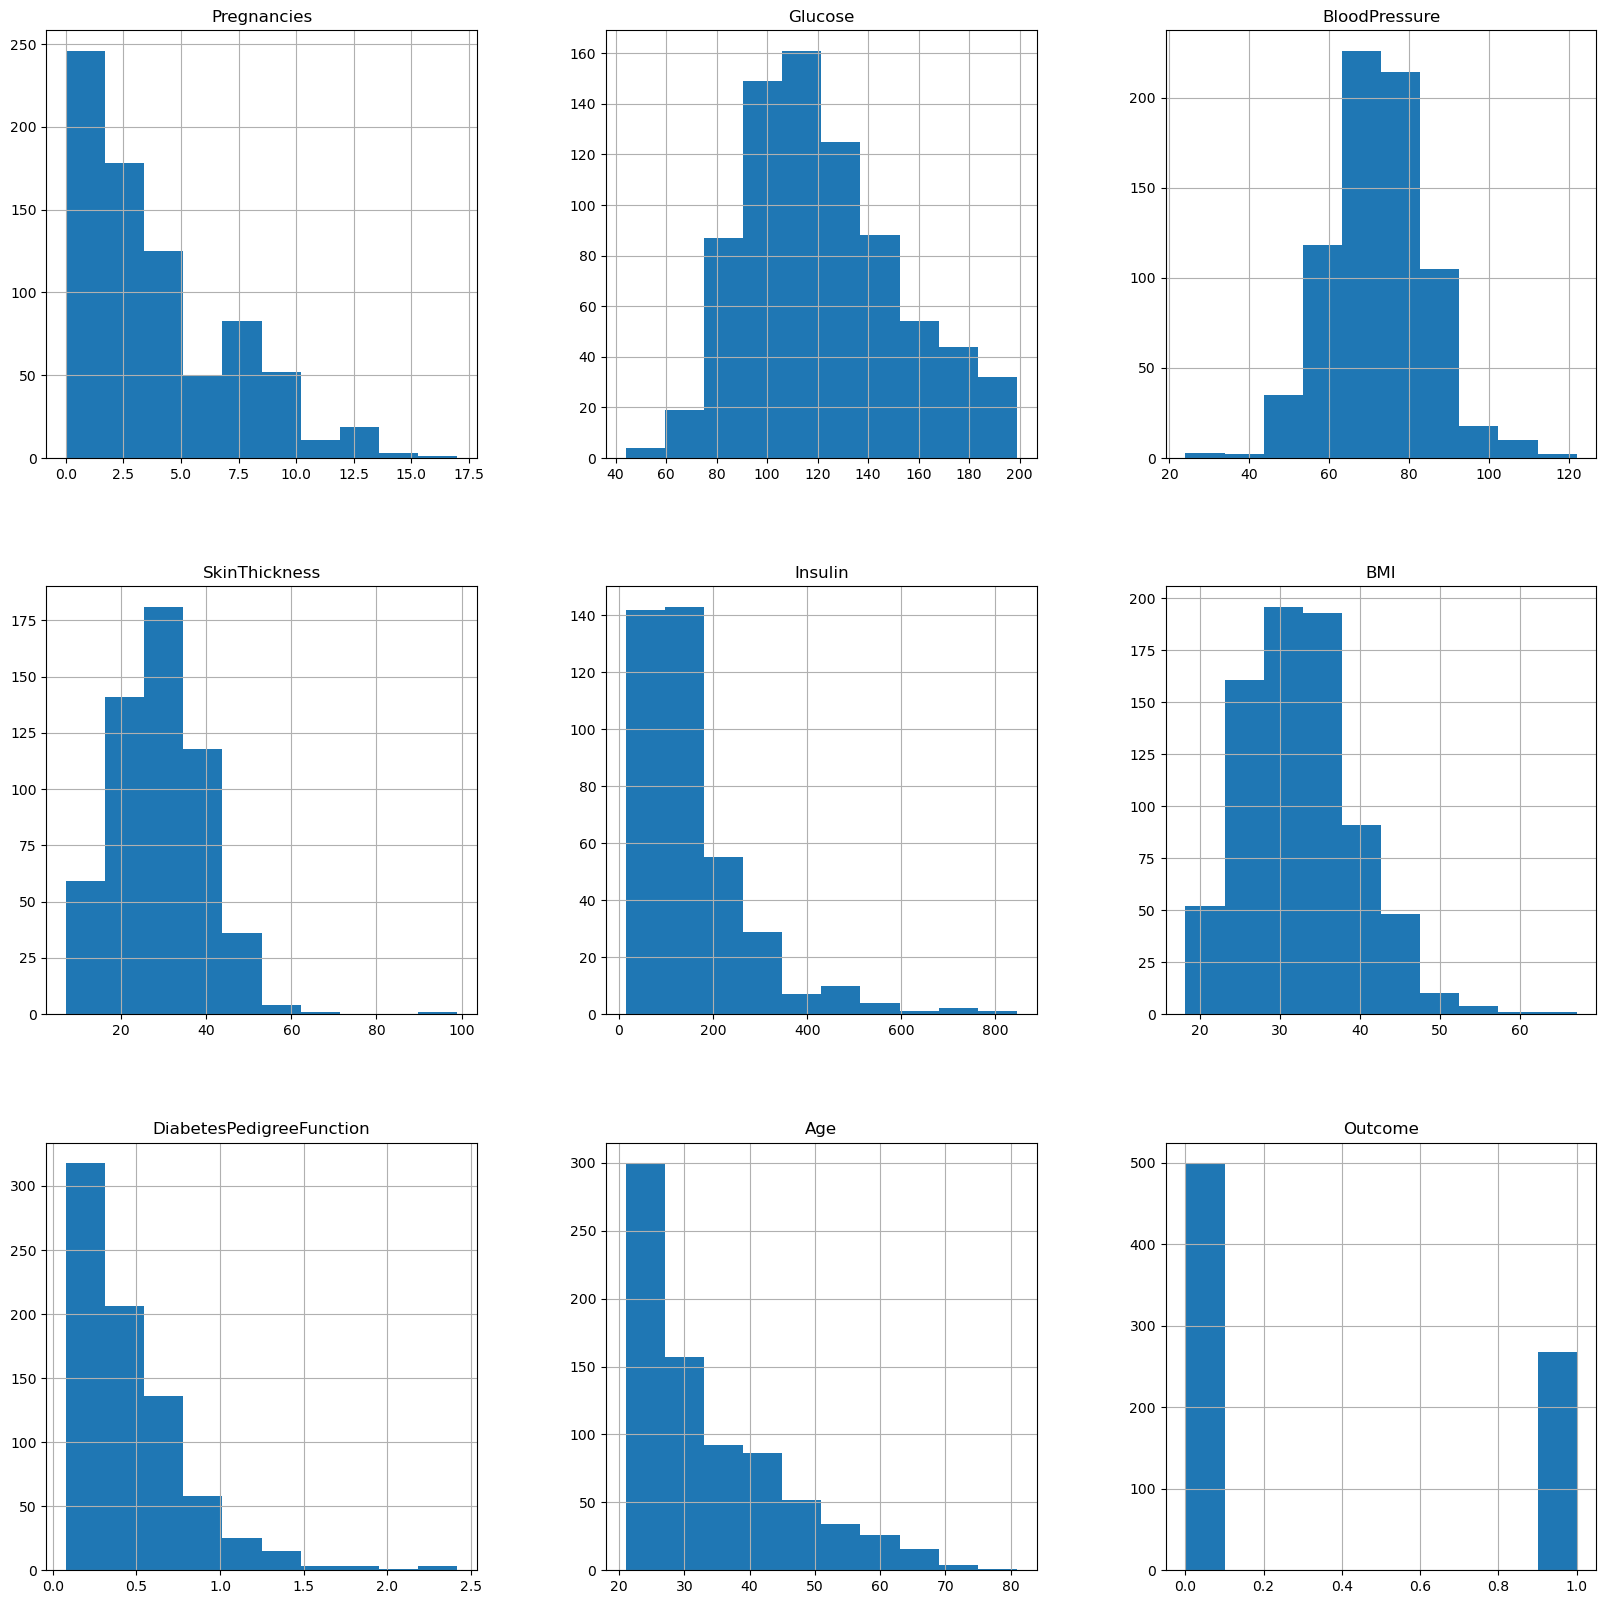

In [13]:
q = df_copy.hist(figsize = (20,20))

In [14]:
# Fill NaN values with the mean. how it's done? we use the fillna() method to replace NaN values with the mean of the column. The inplace=True argument modifies the DataFrame in place, so we don't need to assign it back to df_copy.
df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace = True) 
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(), inplace = True) 
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(), inplace = True) 
df_copy['Insulin'].fillna(df_copy['Insulin'].median(), inplace = True)
df_copy['BMI'].fillna(df_copy['BMI'].median(), inplace = True)

C:\Users\faij ahamed\AppData\Local\Temp\ipykernel_27672\2143254488.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace = True)
C:\Users\faij ahamed\AppData\Local\Temp\ipykernel_27672\2143254488.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

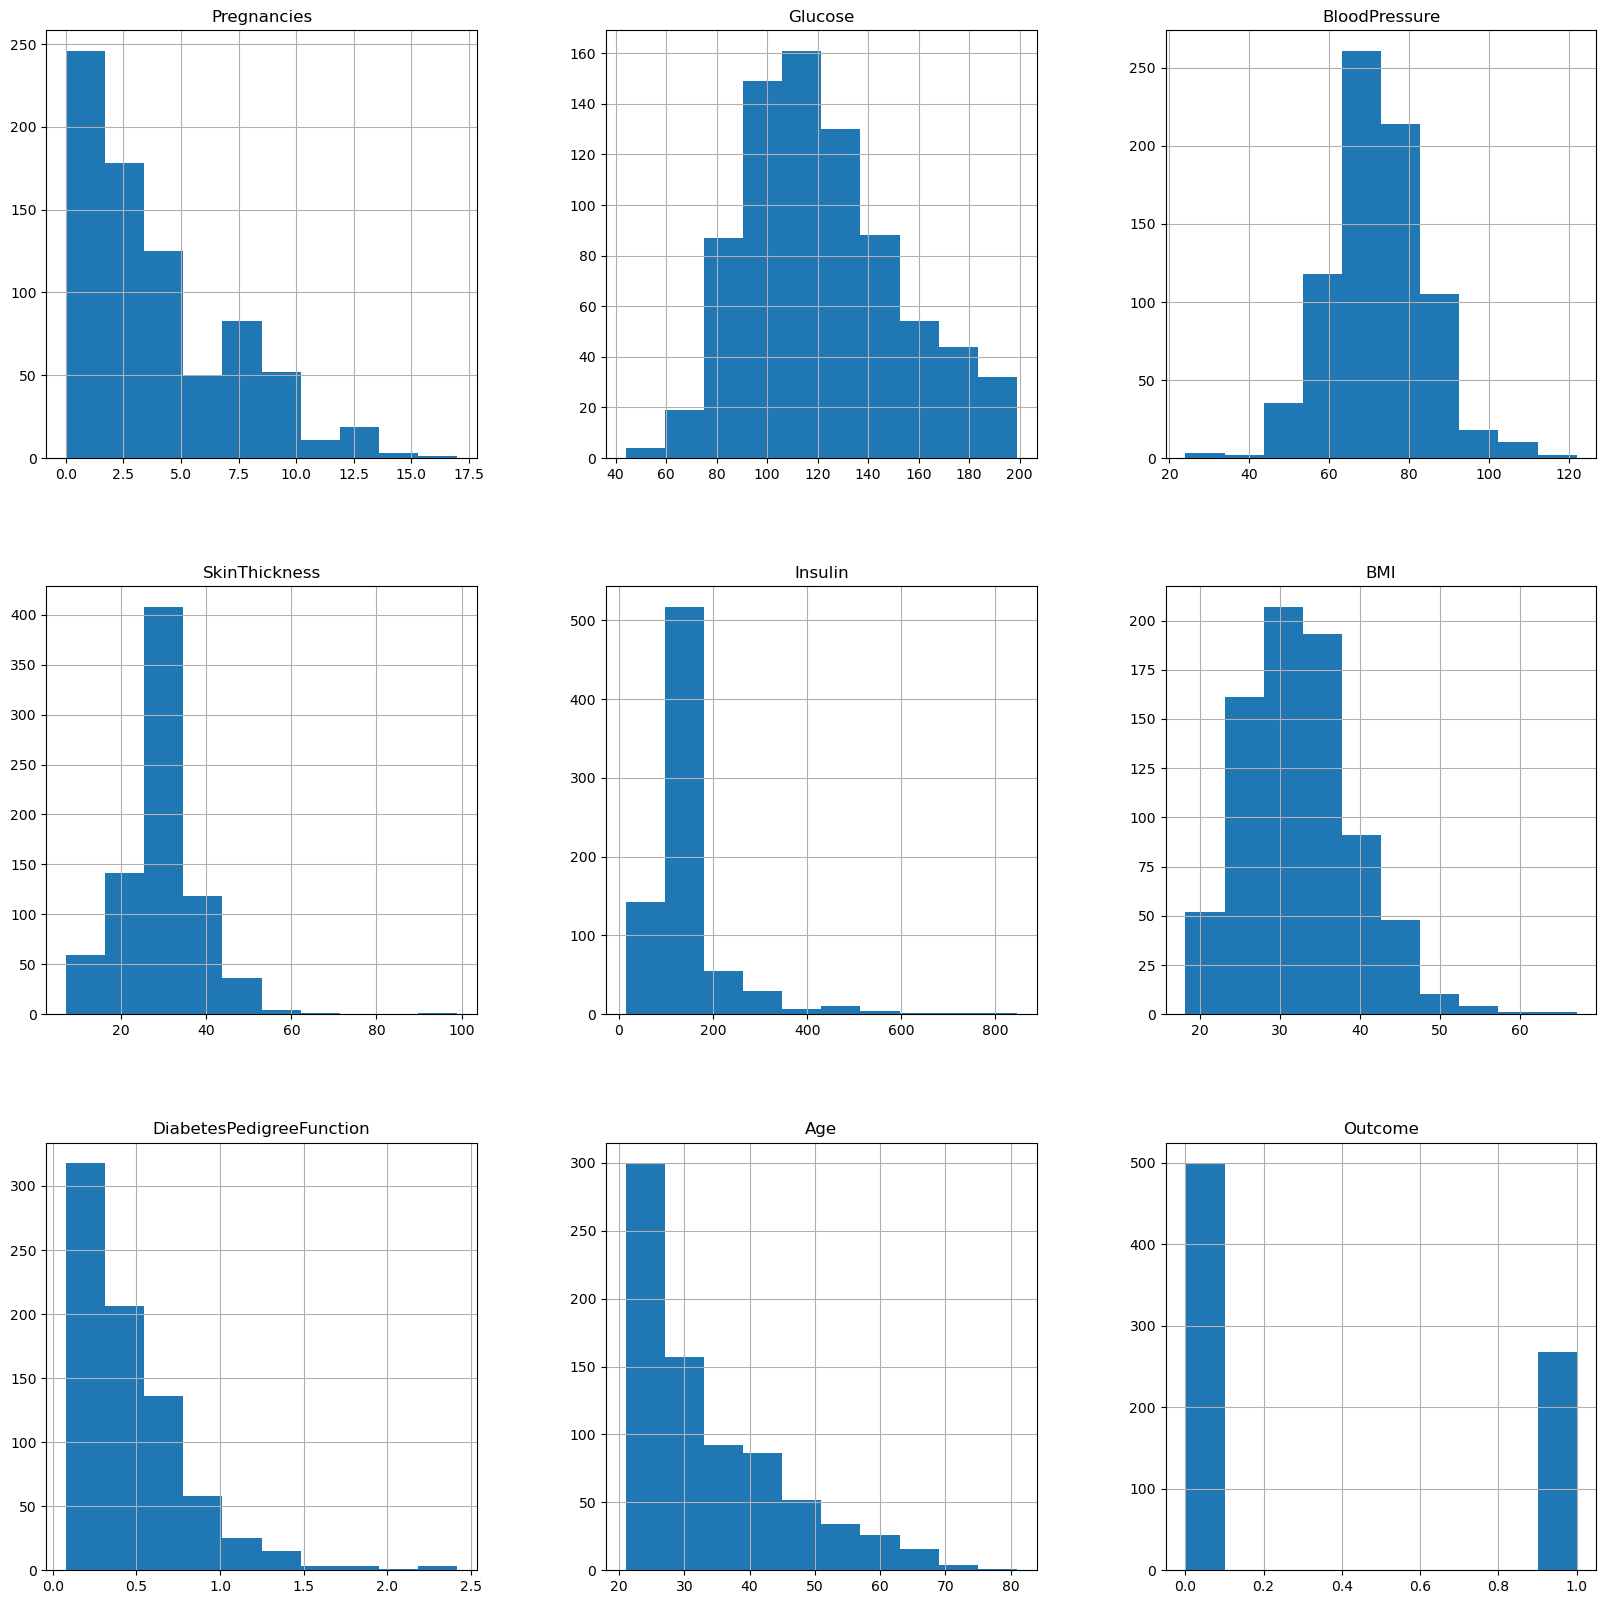

In [15]:
p = df_copy.hist(figsize = (20,20))

In [16]:
print(df_copy.isna().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [17]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.000000,6.00000,17.00
Glucose,768.0,121.686763,30.435949,44.000,99.75000,117.000000,140.25000,199.00
BloodPressure,768.0,72.405184,12.096346,24.000,64.00000,72.202592,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.000000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.000000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.300000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.372500,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.000000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.000000,1.00000,1.00


In [18]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()  # why do we use StandardScaler? We use StandardScaler to standardize the features by removing the mean and scaling to unit variance. This is important for many machine learning algorithms that are sensitive to the scale of the input features.
only_features = df_copy.drop(["Outcome"],axis = 1)
standardized_X = sc_X.fit_transform(only_features) # why do we need to standerdize the features? We need to standardize the features because they have different scales and ranges. For example, the 'Age' feature might range from 20 to 80, while the 'Glucose' feature might range from 0 to 200. Standardizing the features ensures that they are on a similar scale, which can improve the performance of machine learning algorithms.
X =  pd.DataFrame(standardized_X,
        columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']) # this is the final standardized features dataframe that we will use for training our machine learning model. It contains all the features except the target variable 'Outcome', and each feature has been standardized to have a mean of 0 and a standard deviation of 1.
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


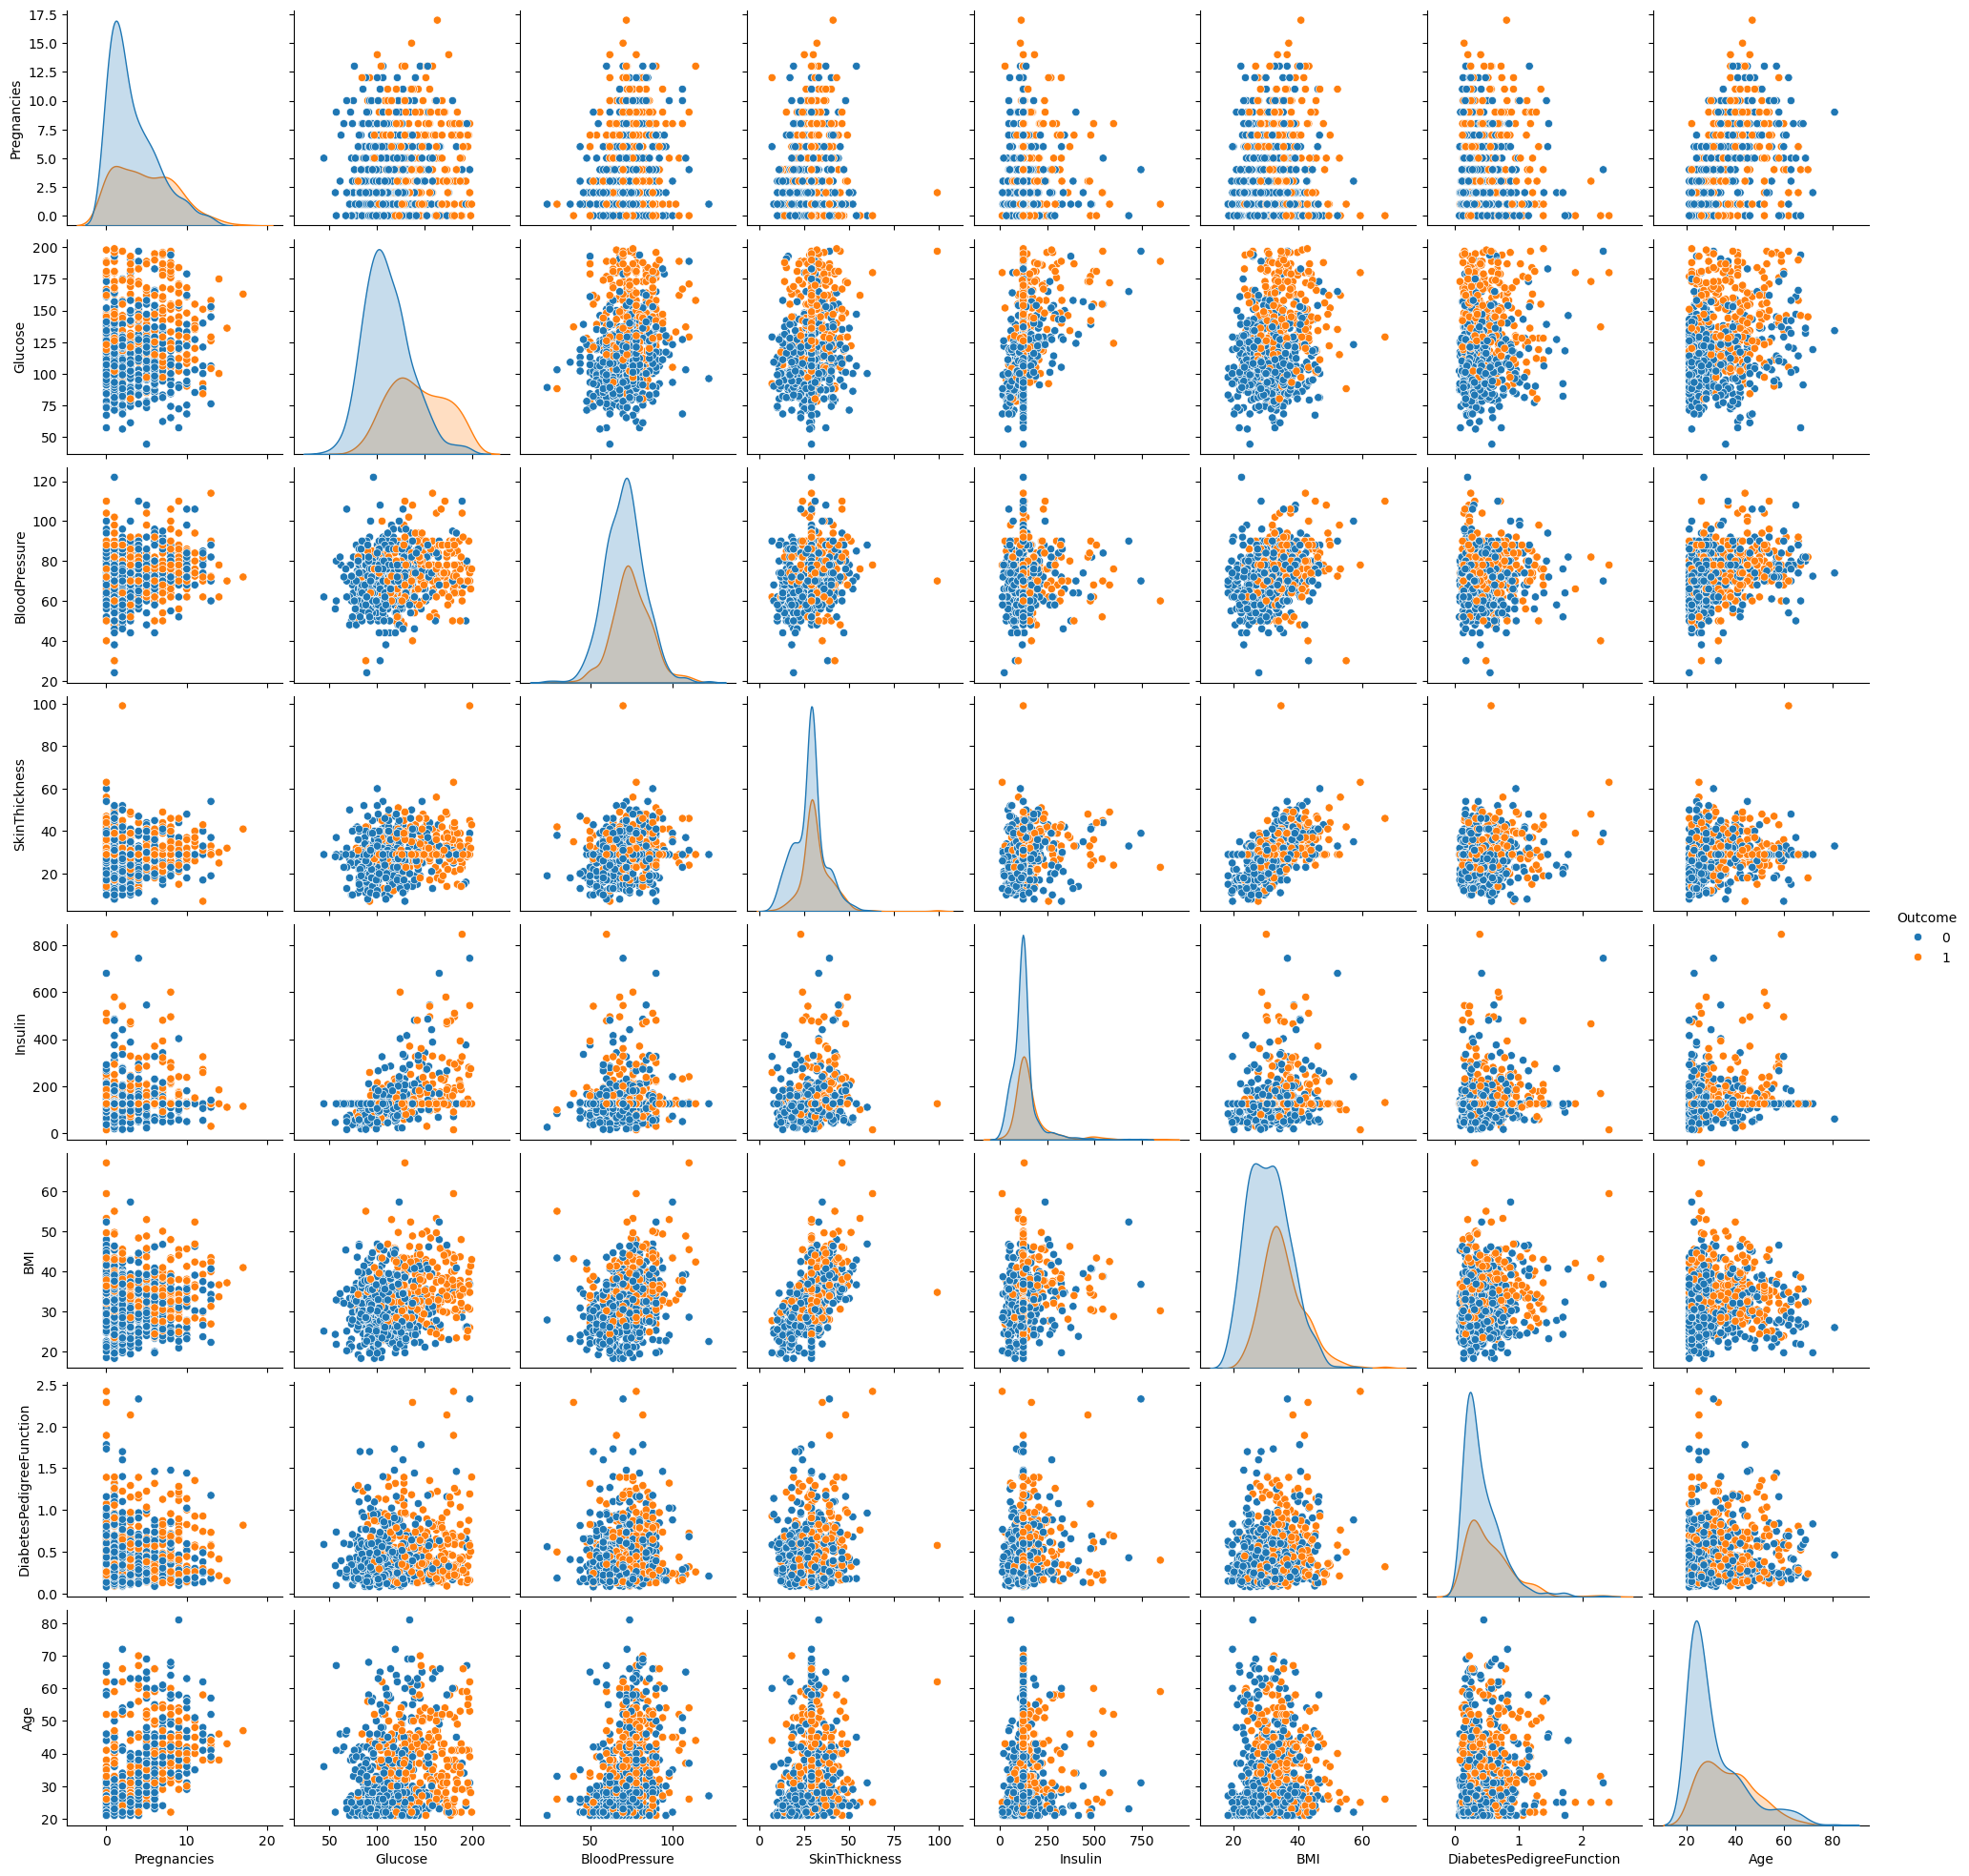

In [19]:
# for pettern observation we can use pairplot to see the relationship between features and target variable. This will help us to understand the data better and also to see if there is any correlation between features and target variable.
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df_copy, hue='Outcome')
plt.show()
# how to interpret the pairplot? The pairplot shows the distribution of each feature and the relationship between features. The diagonal plots show the distribution of each feature, while the off-diagonal plots show the relationship between features. The color of the points indicates the target variable 'Outcome'. We can see that some features have a clear separation between the two classes, while others do not. This information can be useful for feature selection and model building.

In [21]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,-6.476301e-17,1.000652,-1.141852,-0.844885,-0.250952,0.639947,3.906578
Glucose,768.0,-3.561966e-16,1.000652,-2.554131,-0.721221,-0.154088,0.610309,2.541850
BloodPressure,768.0,6.915764e-16,1.000652,-4.004245,-0.695306,-0.016759,0.628269,4.102655
SkinThickness,768.0,-1.526557e-16,1.000652,-2.516429,-0.467597,-0.012301,0.329171,7.955377
Insulin,768.0,1.503427e-17,1.000652,-1.467353,-0.222085,-0.181541,-0.155477,8.170442
BMI,768.0,2.613650e-16,1.000652,-2.074783,-0.721209,-0.022590,0.603256,5.042397
DiabetesPedigreeFunction,768.0,2.451743e-16,1.000652,-1.189553,-0.688969,-0.300128,0.466227,5.883565
Age,768.0,1.931325e-16,1.000652,-1.041549,-0.786286,-0.360847,0.660206,4.063716


In [22]:
y=df_copy['Outcome']
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.neighbors import KNeighborsClassifier #why do we use KNeighborsClassifier? We use KNeighborsClassifier because it is a simple and effective machine learning algorithm that can be used for classification tasks. It works by finding the k-nearest neighbors of a data point and assigning the class label based on the majority class of those neighbors.

test_scores = []
train_scores = []

for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))
    print('k = {} , train score = {} , test score = {}'.format(i,train_scores[i-1],test_scores[i-1]))

k = 1 , train score = 1.0 , test score = 0.6623376623376623
k = 2 , train score = 0.8485342019543974 , test score = 0.6558441558441559
k = 3 , train score = 0.8436482084690554 , test score = 0.6948051948051948
k = 4 , train score = 0.8110749185667753 , test score = 0.7207792207792207
k = 5 , train score = 0.8273615635179153 , test score = 0.7337662337662337
k = 6 , train score = 0.8078175895765473 , test score = 0.7142857142857143
k = 7 , train score = 0.8143322475570033 , test score = 0.7012987012987013
k = 8 , train score = 0.8045602605863192 , test score = 0.7337662337662337
k = 9 , train score = 0.8110749185667753 , test score = 0.7272727272727273
k = 10 , train score = 0.8029315960912052 , test score = 0.7597402597402597
k = 11 , train score = 0.8029315960912052 , test score = 0.7597402597402597
k = 12 , train score = 0.7947882736156352 , test score = 0.7727272727272727
k = 13 , train score = 0.8094462540716613 , test score = 0.7597402597402597
k = 14 , train score = 0.79478827361

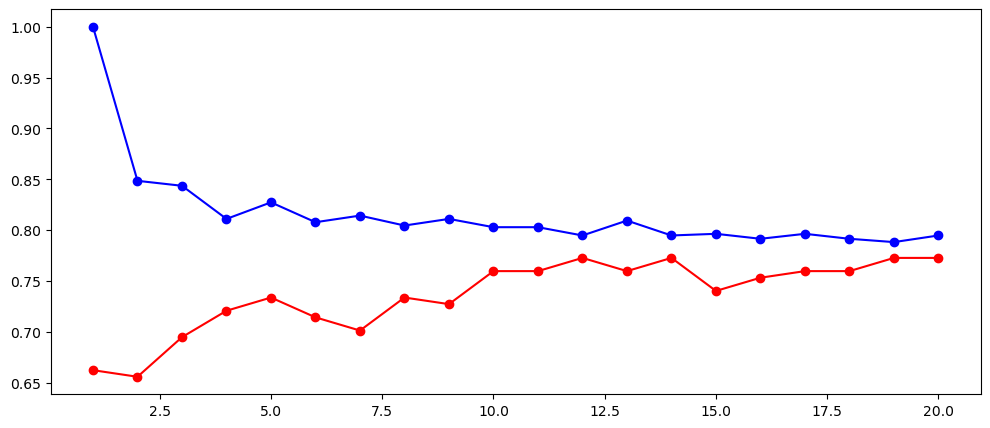

In [25]:
plt.figure(figsize=(12,5))
line1 = plt.plot(range(1,21),train_scores,label='Train Score',marker='o', color='blue')
line2 = plt.plot(range(1,21),test_scores,label='Test Score',marker='o', color='red')

In [26]:
max_test_score = max(test_scores) # Find the maximum test score
best_k = test_scores.index(max_test_score)+1 # Find the index of the maximum test score and add 1 to get the corresponding k value, why 
print('Best k = {} , test score = {}'.format(best_k,max_test_score))

Best k = 12 , test score = 0.7727272727272727


In [27]:
knn = KNeighborsClassifier(best_k)
knn.fit(X_train,y_train)

,n_neighbors,12
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
accuracy = knn.score(X_test,y_test)
print('Accuracy = {}'.format(accuracy))

Accuracy = 0.7727272727272727


In [29]:
#hyperparameter tuning is the process of finding the best set of hyperparameters for a machine learning model. Hyperparameters are parameters that are set before training the model, and they can have a significant impact on the model's performance. In this case, we are tuning the hyperparameter 'k' for the KNeighborsClassifier, which determines the number of neighbors to consider when making predictions. By testing different values of 'k' and evaluating the model's performance on the test set, we can find the value of 'k' that gives us the best accuracy.


In [30]:
y_pred = knn.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        99
           1       0.72      0.60      0.65        55

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



In [31]:
import tkinter as tk
from tkinter import ttk

def submit_data():
    try:
        # Fetch data
        age = int(float(age_entry.get()))
        pregnancies = int(float(pregnancies_entry.get()))
        glucose = int(float(Glucose_entry.get()))
        bloodPressure = int(float(bloodPressure_entry.get()))
        skinThickness = int(float(SkinThickness_entry.get()))
        insulin = int(float(insulin_entry.get()))
        BMI = float(BMI_entry.get())
        DiabetesPedigreeFunction = float(DiabetesPedigreeFunction_entry.get())
        
        user_data = [[pregnancies, glucose, bloodPressure, skinThickness, insulin, BMI, DiabetesPedigreeFunction, age]]
        # Standardize the user input data using the same scaler used for training
        user_data = sc_X.transform(user_data)
        prediction = knn.predict(user_data)

        # Update the EXISTING label instead of creating a new one
        if prediction[0] == 1:
            result_value_label.config(text="You are likely to have diabetes.", fg="red")
        else:
            result_value_label.config(text="You are not likely to have diabetes.", fg="green")
            
    except ValueError:
        # Catches the error if the user leaves a field blank or enters text
        result_value_label.config(text="Error: Please enter valid numbers.", fg="orange")

def clear_data():
    # Helper function to clear all fields so you can easily do it again
    age_entry.delete(0, tk.END)
    pregnancies_entry.delete(0, tk.END)
    Glucose_entry.delete(0, tk.END)
    bloodPressure_entry.delete(0, tk.END)
    SkinThickness_entry.delete(0, tk.END)
    insulin_entry.delete(0, tk.END)
    BMI_entry.delete(0, tk.END)
    DiabetesPedigreeFunction_entry.delete(0, tk.END)
    result_value_label.config(text="") # Clear the result label too

def fill_random_data():
    random_row = df_copy.sample(n=1).iloc[0]
    
    clear_data() # Clear existing data before inserting random data
    
    age_entry.insert(0, random_row['Age'])
    pregnancies_entry.insert(0, random_row['Pregnancies'])
    Glucose_entry.insert(0, random_row['Glucose'])
    bloodPressure_entry.insert(0, random_row['BloodPressure'])
    SkinThickness_entry.insert(0, random_row['SkinThickness'])
    insulin_entry.insert(0, random_row['Insulin'])
    BMI_entry.insert(0, random_row['BMI'])
    DiabetesPedigreeFunction_entry.insert(0, random_row['DiabetesPedigreeFunction'])

# --- GUI SETUP ---
window = tk.Tk()
window.title("Diabetic Prediction App")

frame = tk.Frame(window)
frame.pack(padx=20, pady=20)

# Saving user information
user_info_frame = tk.LabelFrame(frame, text="User Information")
user_info_frame.grid(row=0, column=0, padx=10, pady=10)

first_name_label = tk.Label(user_info_frame, text="Enter your age:")
first_name_label.grid(row=0, column=0)
age_entry = tk.Spinbox(user_info_frame, from_=1, to=120)
age_entry.grid(row=0, column=1)

pregnancies_label = tk.Label(user_info_frame, text="Enter your Pregnancies:")
pregnancies_label.grid(row=1, column=0)
pregnancies_entry = tk.Entry(user_info_frame)
pregnancies_entry.grid(row=1, column=1)

Glucose_label = tk.Label(user_info_frame, text="Enter your Glucose:")
Glucose_label.grid(row=2, column=0)
Glucose_entry = tk.Entry(user_info_frame)
Glucose_entry.grid(row=2, column=1)

bloodPressure_label = tk.Label(user_info_frame, text="Enter your Blood Pressure:")
bloodPressure_label.grid(row=3, column=0)
bloodPressure_entry = tk.Entry(user_info_frame)
bloodPressure_entry.grid(row=3, column=1)

SkinThickness_label = tk.Label(user_info_frame, text="Enter your Skin Thickness:")
SkinThickness_label.grid(row=4, column=0)
SkinThickness_entry = tk.Entry(user_info_frame)
SkinThickness_entry.grid(row=4, column=1)

insulin_label = tk.Label(user_info_frame, text="Enter your Insulin:")
insulin_label.grid(row=5, column=0)
insulin_entry = tk.Entry(user_info_frame)
insulin_entry.grid(row=5, column=1)

BMI_label = tk.Label(user_info_frame, text="Enter your BMI:")
BMI_label.grid(row=6, column=0)
BMI_entry = tk.Entry(user_info_frame)
BMI_entry.grid(row=6, column=1)

DiabetesPedigreeFunction_label = tk.Label(user_info_frame, text="Enter your Diabetes Pedigree Function:")
DiabetesPedigreeFunction_label.grid(row=7, column=0)
DiabetesPedigreeFunction_entry = tk.Entry(user_info_frame)
DiabetesPedigreeFunction_entry.grid(row=7, column=1)

# Add padding to all widgets in the user info frame
for widget in user_info_frame.winfo_children():
    widget.grid_configure(padx=5, pady=5)

# --- ACTION BUTTONS ---
buttons_frame = tk.Frame(frame)
buttons_frame.grid(row=1, column=0, pady=10)

fill_data_button = tk.Button(buttons_frame, text="Fill with Random Data", command=fill_random_data)
fill_data_button.grid(row=0, column=0, padx=5)


clear_button = tk.Button(buttons_frame, text="Clear Data", command=clear_data)
clear_button.grid(row=0, column=3, padx=5)

submit_button = tk.Button(buttons_frame, text="Enter Data", command=submit_data, bg="lightblue")
submit_button.grid(row=0, column=4, padx=5)

# --- PREDICTION RESULT UI ---
# We create this ONCE here, and just update the text later
output_info_frame = tk.LabelFrame(frame, text="Prediction Result")
output_info_frame.grid(row=2, column=0, sticky="news", padx=10, pady=10)

result_label = tk.Label(output_info_frame, text="Prediction Result:")
result_label.grid(row=0, column=0, padx=5, pady=5)

# This label starts blank. submit_data() will modify it.
result_value_label = tk.Label(output_info_frame, text="", font=("Helvetica", 10, "bold"))
result_value_label.grid(row=1, column=0, padx=5, pady=5)

window.mainloop()

c:\Users\faij ahamed\jupiter\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\faij ahamed\jupiter\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\faij ahamed\jupiter\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\faij ahamed\jupiter\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\faij ahamed\jupiter\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\